In [48]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/faizanhaider01/hours-attendence/student_scores.csv


In [49]:
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/hours-attendence/student_scores.csv')

In [50]:
df.sample(5)

,study_hours,attendance_pct,exam_score
55,9.3,62.1,84.1
27,5.6,93.0,92.3
77,1.7,69.3,53.1
68,1.7,52.0,59.3
63,4.2,76.8,67.3


In [51]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [52]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [53]:
from sklearn.linear_model import LinearRegression
L=LinearRegression()

In [54]:
L.fit(X_train,y_train)

LinearRegression()

In [55]:
print(L.coef_)
print(L.intercept_)

[4.2996449  0.42970725]
12.513877809969529


In [56]:
y_pred=L.predict(X_test)

In [57]:
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.6992439844726339
RMSE 7.765910809044814


In [58]:
from sklearn.linear_model import Ridge
R=Ridge(alpha=100)

In [59]:
R.fit(X_train,y_train)

Ridge(alpha=100)

In [60]:
y_pred1=R.predict(X_test)

In [61]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score 0.6989049056179226
RMSE 7.770287303990183


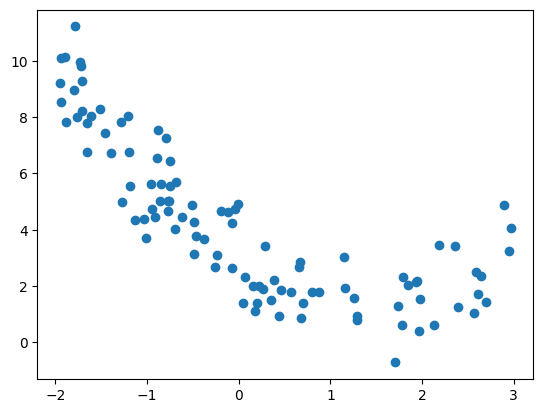

In [62]:
import matplotlib.pyplot as plt
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

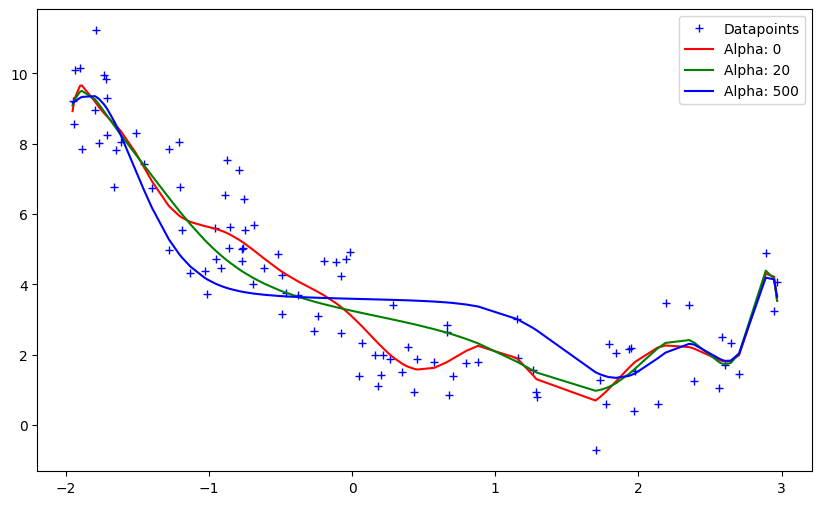

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 500]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()